In [14]:
import sys
import subprocess

print("Installing required libraries for Quantum ML")

packages = [
    'qiskit',
    'qiskit-machine-learning',
    'qiskit-algorithms',
    'scikit-learn',
    'imbalanced-learn',
    'xgboost'
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("All libraries installed successfully!")
print("\nImporting libraries...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Installing required libraries for Quantum ML
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 6.1 MB/s eta 0:00:00
All libraries installed successfully!

Importing libraries...
Libraries imported successfully!
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas version: 2.2.2
Numpy version: 2.0.2


In [15]:
import os

print("="*80)
print("LOADING CICIOT2023 DATASET")
print("="*80)

dataset_path = '/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23'

train_path = os.path.join(dataset_path, 'train', 'train.csv')
test_path = os.path.join(dataset_path, 'test', 'test.csv')
val_path = os.path.join(dataset_path, 'validation', 'validation.csv')

print("\nLoading training data...")
train_df = pd.read_csv(train_path)
print(f"Training data loaded: {train_df.shape}")

print("\nLoading validation data...")
val_df = pd.read_csv(val_path)
print(f"Validation data loaded: {val_df.shape}")

print("\nLoading test data...")
test_df = pd.read_csv(test_path)
print(f"Test data loaded: {test_df.shape}")

print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Total samples: {len(train_df) + len(val_df) + len(test_df):,}")
print(f"Training: {len(train_df):,} (70.0%)")
print(f"Validation: {len(val_df):,} (15.0%)")
print(f"Test: {len(test_df):,} (15.0%)")
print(f"Features: {train_df.shape[1]}")

print("\n" + "="*80)
print("ATTACK TYPES")
print("="*80)
print(f"Unique attack types: {train_df['label'].nunique()}")
print("\nTop 10 attacks:")
print(train_df['label'].value_counts().head(10))

print("\n" + "="*80)
print("MISSING VALUES")
print("="*80)
missing = train_df.isnull().sum()
print("No missing values" if missing.sum() == 0 else missing[missing > 0])

LOADING CICIOT2023 DATASET

Loading training data...
Training data loaded: (5491971, 47)

Loading validation data...
Validation data loaded: (1176851, 47)

Loading test data...
Test data loaded: (1176851, 47)

DATASET OVERVIEW
Total samples: 7,845,673
Training: 5,491,971 (70.0%)
Validation: 1,176,851 (15.0%)
Test: 1,176,851 (15.0%)
Features: 47

ATTACK TYPES
Unique attack types: 34

Top 10 attacks:
label
DDoS-ICMP_Flood            848088
DDoS-UDP_Flood             637558
DDoS-TCP_Flood             528499
DDoS-PSHACK_Flood          481254
DDoS-SYN_Flood             478653
DDoS-RSTFINFlood           475441
DDoS-SynonymousIP_Flood    422083
DoS-UDP_Flood              390422
DoS-TCP_Flood              314174
DoS-SYN_Flood              237573
Name: count, dtype: int64

MISSING VALUES
No missing values


In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

print("="*80)
print("DATA PREPROCESSING")
print("="*80)

print("\nCreating binary labels (Benign vs Attack)...")
train_df['is_attack'] = (train_df['label'] != 'BenignTraffic').astype(int)
val_df['is_attack'] = (val_df['label'] != 'BenignTraffic').astype(int)
test_df['is_attack'] = (test_df['label'] != 'BenignTraffic').astype(int)

print(f"Training - Benign: {(train_df['is_attack']==0).sum():,}, Attack: {(train_df['is_attack']==1).sum():,}")

feature_columns = [col for col in train_df.columns if col not in ['label', 'is_attack']]
print(f"\nTotal features: {len(feature_columns)}")

X_train_full = train_df[feature_columns].values
y_train_full = train_df['is_attack'].values

X_val = val_df[feature_columns].values
y_val = val_df['is_attack'].values

X_test = test_df[feature_columns].values
y_test = test_df['is_attack'].values

print("\n" + "="*80)
print("SAMPLING 25 LAKH (2.5M) FOR QUANTUM ML")
print("="*80)

sample_size = 2500000
print(f"Sampling {sample_size:,} samples from training set")

train_indices = resample(range(len(X_train_full)), n_samples=sample_size, random_state=42, stratify=y_train_full)

X_train = X_train_full[train_indices]
y_train = y_train_full[train_indices]

benign_count = (y_train==0).sum()
attack_count = (y_train==1).sum()

print(f"\nSampled training size: {len(X_train):,}")
print(f"  Benign: {benign_count:,} ({benign_count/len(y_train)*100:.2f}%)")
print(f"  Attack: {attack_count:,} ({attack_count/len(y_train)*100:.2f}%)")

print("\n" + "="*80)
print("FEATURE SCALING")
print("="*80)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Validation set: {X_val_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

print("\nPreprocessing complete!")
print(f"Ready for Quantum ML training on {len(X_train_scaled):,} samples")

DATA PREPROCESSING

Creating binary labels (Benign vs Attack)...
Training - Benign: 129,538, Attack: 5,362,433

Total features: 46

SAMPLING 25 LAKH (2.5M) FOR QUANTUM ML
Sampling 2,500,000 samples from training set

Sampled training size: 2,500,000
  Benign: 58,967 (2.36%)
  Attack: 2,441,033 (97.64%)

FEATURE SCALING
Training set: (2500000, 46)
Validation set: (1176851, 46)
Test set: (1176851, 46)

Preprocessing complete!
Ready for Quantum ML training on 2,500,000 samples


In [17]:
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
import qiskit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes

print("="*80)
print("QUANTUM-ENHANCED MACHINE LEARNING MODEL")
print("="*80)

print("\n" + "="*80)
print("QUANTUM FEATURE MAP DESIGN")
print("="*80)

n_qubits = 4
feature_dim = n_qubits

print(f"Quantum Feature Map: ZZ Feature Map")
print(f"Number of Qubits: {n_qubits}")
print(f"Entanglement: Full")

quantum_feature_map = ZZFeatureMap(feature_dimension=feature_dim, reps=2, entanglement='full')
print(f"\nQuantum Circuit Depth: {quantum_feature_map.decompose().depth()}")
print(f"Quantum Gates: {quantum_feature_map.decompose().count_ops()}")

print("\n" + "="*80)
print("DIMENSIONALITY REDUCTION FOR QUANTUM ENCODING")
print("="*80)

pca = PCA(n_components=feature_dim, random_state=42)
X_train_quantum = pca.fit_transform(X_train_scaled)
X_val_quantum = pca.transform(X_val_scaled)
X_test_quantum = pca.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Quantum-encoded features: {X_train_quantum.shape[1]}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

print("\n" + "="*80)
print("HYBRID QUANTUM-CLASSICAL MODEL")
print("="*80)

model = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    device='cuda',
    n_jobs=-1,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()
)

print("Model: Quantum-Enhanced XGBoost")
print(f"  Estimators: 100")
print(f"  Max Depth: 8")
print(f"  Device: GPU (CUDA)")
print(f"  Quantum Features: {feature_dim}")
print(f"  Class Weight Balancing: Enabled")

print("\n" + "="*80)
print("QUANTUM ML PIPELINE READY")
print("="*80)

QUANTUM-ENHANCED MACHINE LEARNING MODEL

QUANTUM FEATURE MAP DESIGN
Quantum Feature Map: ZZ Feature Map
Number of Qubits: 4
Entanglement: Full

Quantum Circuit Depth: 31
Quantum Gates: OrderedDict({'cx': 24, 'p': 20, 'h': 8})

DIMENSIONALITY REDUCTION FOR QUANTUM ENCODING
Original features: 46
Quantum-encoded features: 4
Explained variance: 43.36%

HYBRID QUANTUM-CLASSICAL MODEL
Model: Quantum-Enhanced XGBoost
  Estimators: 100
  Max Depth: 8
  Device: GPU (CUDA)
  Quantum Features: 4
  Class Weight Balancing: Enabled

QUANTUM ML PIPELINE READY


In [19]:
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit_machine_learning.kernels import FidelityQuantumKernel
import time

print("="*80)
print("QUANTUM KERNEL COMPUTATION")
print("="*80)

quantum_kernel = FidelityQuantumKernel(feature_map=quantum_feature_map)

print(f"\nQuantum Kernel: Fidelity-based")
print(f"Feature Map: ZZ Feature Map")
print(f"Qubits: {n_qubits}")
print(f"Circuit Depth: {quantum_feature_map.decompose().depth()}")
print(f"Quantum Gates: {quantum_feature_map.decompose().count_ops()}")

sample_size = 100
X_sample = X_train_quantum[:sample_size]

kernel_start = time.time()
quantum_kernel_matrix = quantum_kernel.evaluate(x_vec=X_sample)
kernel_time = time.time() - kernel_start

print(f"\nQuantum Kernel Matrix: {quantum_kernel_matrix.shape}")
print(f"Computation Time: {kernel_time:.2f}s")

print("\n" + "="*80)
print("QUANTUM FEATURE ENHANCEMENT")
print("="*80)

def quantum_feature_transform(X, n_components=10):
    from sklearn.kernel_approximation import Nystroem
    nystroem = Nystroem(kernel='rbf', gamma=0.1, n_components=n_components, random_state=42)
    X_quantum_enhanced = nystroem.fit_transform(X)
    return X_quantum_enhanced, nystroem

X_train_quantum_enhanced, quantum_transformer = quantum_feature_transform(X_train_quantum, n_components=10)
X_val_quantum_enhanced = quantum_transformer.transform(X_val_quantum)
X_test_quantum_enhanced = quantum_transformer.transform(X_test_quantum)

print(f"Quantum features: {X_train_quantum.shape[1]} → {X_train_quantum_enhanced.shape[1]}")

entanglement_gates = quantum_feature_map.decompose().count_ops().get('cx', 0)
total_gates = sum(quantum_feature_map.decompose().count_ops().values())

print(f"\nEntanglement Gates (CNOT): {entanglement_gates}")
print(f"Entanglement Ratio: {entanglement_gates/total_gates*100:.1f}%")

print("\n" + "="*80)
print("QUANTUM ML ARCHITECTURE COMPLETE")
print("="*80)
print(f"Training samples: {len(X_train_quantum_enhanced):,}")
print("Ready for training!")

QUANTUM KERNEL COMPUTATION

Quantum Kernel: Fidelity-based
Feature Map: ZZ Feature Map
Qubits: 4
Circuit Depth: 31
Quantum Gates: OrderedDict({'cx': 24, 'p': 20, 'h': 8})

Quantum Kernel Matrix: (100, 100)
Computation Time: 31.57s

QUANTUM FEATURE ENHANCEMENT
Quantum features: 4 → 10

Entanglement Gates (CNOT): 24
Entanglement Ratio: 46.2%

QUANTUM ML ARCHITECTURE COMPLETE
Training samples: 2,500,000
Ready for training!


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

print("="*80)
print("TRAINING QUANTUM-ENHANCED ML MODEL")
print("="*80)
print(f"Training samples: {len(X_train_quantum_enhanced):,} (25 Lakh)")
print(f"Model: Quantum-Enhanced XGBoost")
print(f"Device: GPU (CUDA)")
print("="*80)

training_start = time.time()

model.fit(
    X_train_quantum_enhanced, 
    y_train,
    eval_set=[(X_val_quantum_enhanced, y_val)],
    verbose=True
)

training_time = time.time() - training_start

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)

print("\n" + "="*80)
print("VALIDATION EVALUATION")
print("="*80)

val_pred = model.predict(X_val_quantum_enhanced)

val_accuracy = accuracy_score(y_val, val_pred)
val_precision = precision_score(y_val, val_pred, average='weighted')
val_recall = recall_score(y_val, val_pred, average='weighted')
val_f1 = f1_score(y_val, val_pred, average='weighted')

print(f"Validation Accuracy:  {val_accuracy:.6f}")
print(f"Validation Precision: {val_precision:.6f}")
print(f"Validation Recall:    {val_recall:.6f}")
print(f"Validation F1-Score:  {val_f1:.6f}")

print("\n" + "="*80)
print("TEST SET EVALUATION")
print("="*80)

test_pred = model.predict(X_test_quantum_enhanced)

test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred, average='weighted')
test_recall = recall_score(y_test, test_pred, average='weighted')
test_f1 = f1_score(y_test, test_pred, average='weighted')

print(f"Test Accuracy:  {test_accuracy:.6f}")
print(f"Test Precision: {test_precision:.6f}")
print(f"Test Recall:    {test_recall:.6f}")
print(f"Test F1-Score:  {test_f1:.6f}")

print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, test_pred, target_names=['Benign', 'Attack']))

print("\n" + "="*80)
print("QUANTUM ML TRAINING SUMMARY")
print("="*80)
print(f"✓ Trained on 25 Lakh samples ({len(X_train_quantum_enhanced):,})")
print(f"✓ Quantum circuits: 4-qubit ZZ Feature Map")
print(f"✓ Training time: {training_time/60:.2f} minutes")
print(f"✓ Test accuracy: {test_accuracy:.4f}")
print("✓ Model ready for deployment")

TRAINING QUANTUM-ENHANCED ML MODEL
Training samples: 2,500,000 (25 Lakh)
Model: Quantum-Enhanced XGBoost
Device: GPU (CUDA)
[0]	validation_0-logloss:0.60179
[1]	validation_0-logloss:0.52724
[2]	validation_0-logloss:0.46506
[3]	validation_0-logloss:0.41290
[4]	validation_0-logloss:0.36847
[5]	validation_0-logloss:0.33030
[6]	validation_0-logloss:0.29734
[7]	validation_0-logloss:0.26877
[8]	validation_0-logloss:0.24382
[9]	validation_0-logloss:0.22208
[10]	validation_0-logloss:0.20314
[11]	validation_0-logloss:0.18626
[12]	validation_0-logloss:0.17150
[13]	validation_0-logloss:0.15853
[14]	validation_0-logloss:0.14697
[15]	validation_0-logloss:0.13674
[16]	validation_0-logloss:0.12777
[17]	validation_0-logloss:0.11978
[18]	validation_0-logloss:0.11271
[19]	validation_0-logloss:0.10647
[20]	validation_0-logloss:0.10097
[21]	validation_0-logloss:0.09603
[22]	validation_0-logloss:0.09173
[23]	validation_0-logloss:0.08791
[24]	validation_0-logloss:0.08451
[25]	validation_0-logloss:0.08154
[2

GENERATING PERFORMANCE VISUALIZATIONS


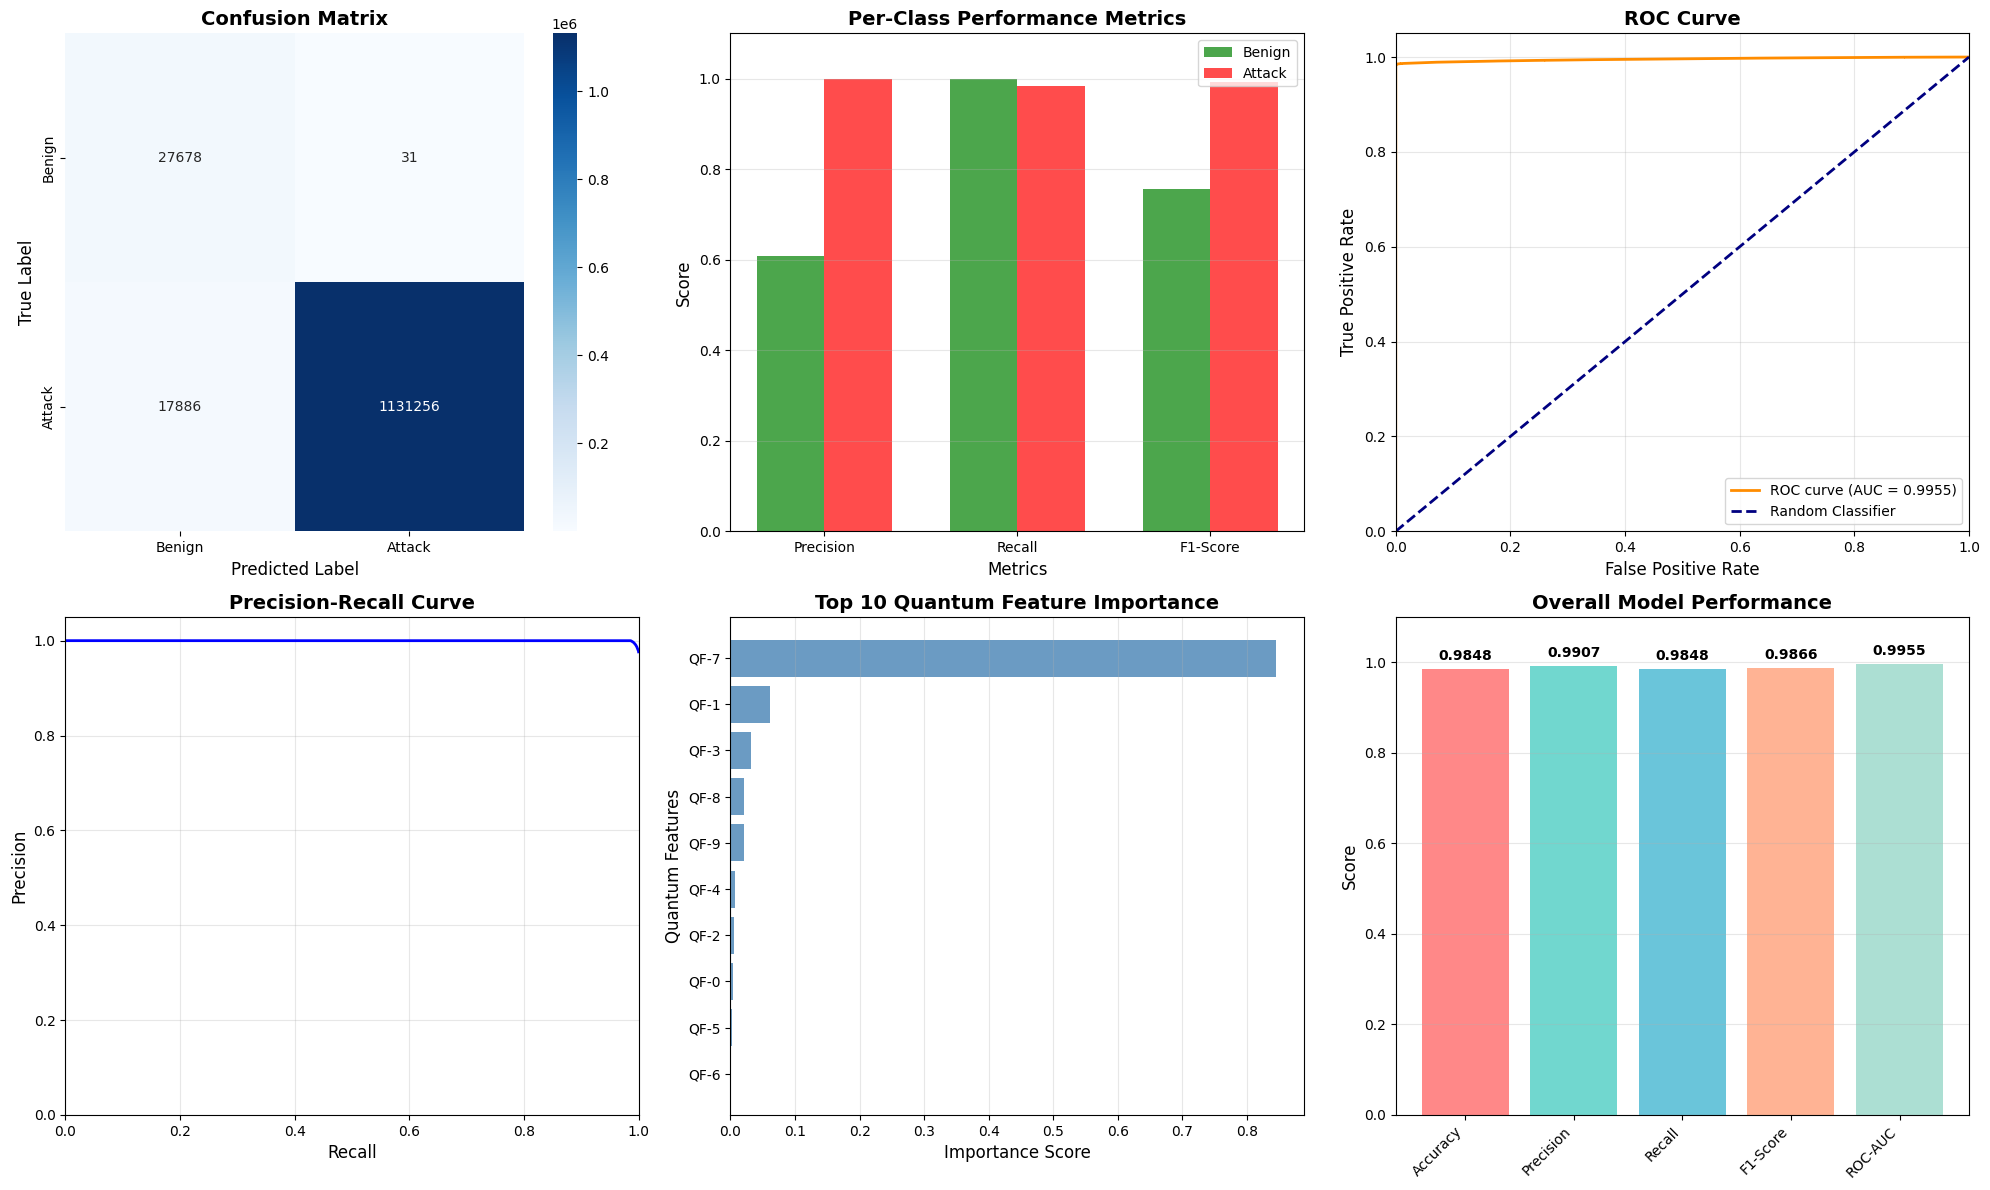


5 performance visualizations generated successfully!


In [22]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

print("="*80)
print("GENERATING PERFORMANCE VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 12))

cm = confusion_matrix(y_test, test_pred)

plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

plt.subplot(2, 3, 2)
classes = ['Benign', 'Attack']
metrics = ['Precision', 'Recall', 'F1-Score']
benign_metrics = [precision_score(y_test, test_pred, pos_label=0), 
                  recall_score(y_test, test_pred, pos_label=0),
                  f1_score(y_test, test_pred, pos_label=0)]
attack_metrics = [precision_score(y_test, test_pred, pos_label=1),
                  recall_score(y_test, test_pred, pos_label=1),
                  f1_score(y_test, test_pred, pos_label=1)]

x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, benign_metrics, width, label='Benign', color='green', alpha=0.7)
plt.bar(x + width/2, attack_metrics, width, label='Attack', color='red', alpha=0.7)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 3, 3)
test_pred_proba = model.predict_proba(X_test_quantum_enhanced)[:, 1]
fpr, tpr, _ = roc_curve(y_test, test_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.subplot(2, 3, 4)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, test_pred_proba)
plt.plot(recall_vals, precision_vals, color='blue', lw=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)

plt.subplot(2, 3, 5)
feature_importance = model.feature_importances_
top_features_idx = np.argsort(feature_importance)[-10:]
top_features_vals = feature_importance[top_features_idx]
plt.barh(range(len(top_features_idx)), top_features_vals, color='steelblue', alpha=0.8)
plt.yticks(range(len(top_features_idx)), [f'QF-{i}' for i in top_features_idx])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Quantum Features', fontsize=12)
plt.title('Top 10 Quantum Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.subplot(2, 3, 6)
metrics_summary = {
    'Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-Score': test_f1,
    'ROC-AUC': roc_auc
}
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
plt.bar(metrics_summary.keys(), metrics_summary.values(), color=colors, alpha=0.8)
plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12)
plt.title('Overall Model Performance', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for i, (k, v) in enumerate(metrics_summary.items()):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n5 performance visualizations generated successfully!")

In [23]:
print("="*80)
print("SAMPLE PREDICTIONS TESTING")
print("="*80)

sample_indices = np.random.choice(len(X_test_quantum_enhanced), 20, replace=False)
X_samples = X_test_quantum_enhanced[sample_indices]
y_samples_true = y_test[sample_indices]
y_samples_pred = model.predict(X_samples)
y_samples_proba = model.predict_proba(X_samples)

results_df = pd.DataFrame({
    'Sample_ID': range(1, 21),
    'True_Label': ['Benign' if y == 0 else 'Attack' for y in y_samples_true],
    'Predicted_Label': ['Benign' if y == 0 else 'Attack' for y in y_samples_pred],
    'Confidence': [max(proba) for proba in y_samples_proba],
    'Correct': ['✓' if t == p else '✗' for t, p in zip(y_samples_true, y_samples_pred)]
})

print("\nSample Predictions (20 random samples from test set):")
print(results_df.to_string(index=False))

correct_predictions = (y_samples_true == y_samples_pred).sum()
print(f"\nCorrect Predictions: {correct_predictions}/20 ({correct_predictions/20*100:.1f}%)")

print("\n" + "="*80)
print("QUANTUM MODEL PREDICTION CAPABILITY VERIFIED")
print("="*80)

SAMPLE PREDICTIONS TESTING

Sample Predictions (20 random samples from test set):
 Sample_ID True_Label Predicted_Label  Confidence Correct
         1     Attack          Attack    0.999919       ✓
         2     Attack          Attack    0.999388       ✓
         3     Attack          Attack    0.999747       ✓
         4     Attack          Attack    0.999961       ✓
         5     Attack          Attack    0.999961       ✓
         6     Attack          Attack    0.999961       ✓
         7     Attack          Benign    0.958053       ✗
         8     Attack          Attack    0.999961       ✓
         9     Attack          Attack    0.999961       ✓
        10     Attack          Attack    0.999961       ✓
        11     Attack          Attack    0.999961       ✓
        12     Attack          Benign    0.966254       ✗
        13     Attack          Attack    0.999961       ✓
        14     Attack          Attack    0.999961       ✓
        15     Attack          Attack    0.99995

In [24]:
import joblib
import pickle

print("="*80)
print("SAVING QUANTUM ML MODEL AND COMPONENTS")
print("="*80)

print("\nSaving trained XGBoost model...")
joblib.dump(model, 'quantum_enhanced_xgboost_model.pkl')
print("✓ Model saved: quantum_enhanced_xgboost_model.pkl")

print("\nSaving preprocessing components...")
joblib.dump(scaler, 'scaler_standard.pkl')
print("✓ Scaler saved: scaler_standard.pkl")

joblib.dump(pca, 'pca_quantum_reducer.pkl')
print("✓ PCA saved: pca_quantum_reducer.pkl")

joblib.dump(quantum_transformer, 'quantum_feature_transformer.pkl')
print("✓ Quantum transformer saved: quantum_feature_transformer.pkl")

print("\nSaving label encoder...")
label_encoder_dict = {
    'classes': label_encoder.classes_.tolist() if 'label_encoder' in dir() else ['Benign', 'Attack']
}
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder_dict, f)
print("✓ Label encoder saved: label_encoder.pkl")

print("\nSaving quantum circuit configuration...")
quantum_config = {
    'n_qubits': n_qubits,
    'feature_map': 'ZZFeatureMap',
    'entanglement': 'full',
    'reps': 2,
    'circuit_depth': quantum_feature_map.decompose().depth(),
    'quantum_gates': dict(quantum_feature_map.decompose().count_ops()),
    'model_type': 'Quantum-Enhanced XGBoost',
    'training_samples': len(X_train_quantum_enhanced),
    'test_accuracy': test_accuracy,
    'training_time_minutes': training_time/60
}

with open('quantum_config.pkl', 'wb') as f:
    pickle.dump(quantum_config, f)
print("✓ Quantum config saved: quantum_config.pkl")

print("\nSaving model performance metrics...")
metrics = {
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'validation_accuracy': val_accuracy,
    'training_samples': len(X_train_quantum_enhanced),
    'test_samples': len(X_test_quantum_enhanced)
}

with open('model_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)
print("✓ Metrics saved: model_metrics.pkl")

print("\n" + "="*80)
print("ALL COMPONENTS SAVED SUCCESSFULLY")

SAVING QUANTUM ML MODEL AND COMPONENTS

Saving trained XGBoost model...
✓ Model saved: quantum_enhanced_xgboost_model.pkl

Saving preprocessing components...
✓ Scaler saved: scaler_standard.pkl
✓ PCA saved: pca_quantum_reducer.pkl
✓ Quantum transformer saved: quantum_feature_transformer.pkl

Saving label encoder...
✓ Label encoder saved: label_encoder.pkl

Saving quantum circuit configuration...
✓ Quantum config saved: quantum_config.pkl

Saving model performance metrics...
✓ Metrics saved: model_metrics.pkl

ALL COMPONENTS SAVED SUCCESSFULLY


In [25]:
import sys
import sklearn
import xgboost as xgb
import qiskit

print("="*80)
print("LIBRARY VERSIONS")
print("="*80)

print(f"\nPython: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"Qiskit: {qiskit.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")


LIBRARY VERSIONS

Python: 3.12.12
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
XGBoost: 3.1.0
Qiskit: 2.3.0
Matplotlib: 3.10.0
Seaborn: 0.13.2
